# 特征选择、PCA 与模型比较

在03笔记里面需要比较 Original、Pearson 特征选择（FS）和 PCA。Original 就是保留02后的输入，包含独热编码和 Min-Max 处理。FS 保留部分已有输入列。PCA 将输入转换为主成分。分类器使用决策树（DT）和随机森林（RF）。比较范围限于当前二分类数据和这一次固定划分。

现在读取02处理好之后的numpy数据文件 `data/processed/model_inputs.npz`。   

In [15]:
# 1.读取隔离划分并核对输入和标签
from pathlib import Path
from time import perf_counter
import hashlib
import json 
import platform
import numpy as np
import pandas as pd
from IPython.display import display

root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
input_path = root / "data" / "processed" / "model_inputs.npz"
assert input_path.is_file(), f"找不到隔离划分输入：{input_path}"
required_keys = {
    "group_X_train", "group_X_test", "group_y_train", "group_y_test",
    "group_train_index", "group_test_index", "group_train_type", "group_test_type",
    "group_feature_names", "input_fields", "raw_sha256", "random_seed", "schema_version",
}
with np.load(input_path, allow_pickle=False) as stored:
    assert set(stored.files) == required_keys, "文件内容与隔离划分交接约定不同"
    X_train = stored["group_X_train"].copy()
    X_test = stored["group_X_test"].copy()
    y_train = stored["group_y_train"].copy()
    y_test = stored["group_y_test"].copy()
    train_index = stored["group_train_index"].copy()
    test_index = stored["group_test_index"].copy()
    train_type = stored["group_train_type"].copy()
    test_type = stored["group_test_type"].copy()
    feature_names = stored["group_feature_names"].copy()
    input_columns = stored["input_fields"].copy()
    raw_sha256 = stored["raw_sha256"].item()
    random_seed = int(stored["random_seed"].item())
    schema_version = stored["schema_version"].item()

expected_sha256 = "65d5465df1809b984fd10e4703bc9c012d1aefd11803773856364216f0a3520d"
assert raw_sha256 == expected_sha256 and schema_version == "1"
assert X_train.shape == (360464, 88) and X_test.shape == (89508, 88)
assert X_train.dtype == np.float64 and X_test.dtype == np.float64
assert len(feature_names) == 88 and len(set(feature_names)) == 88
assert len(input_columns) == 38
assert not set(input_columns) & {"label", "type", "ts", "src_ip", "dst_ip", "src_port", "dst_port"}
for matrix, labels, indices, types in [
    (X_train, y_train, train_index, train_type),
    (X_test, y_test, test_index, test_type),
]:
    assert matrix.shape[0] == len(labels) == len(indices) == len(types)
    assert set(np.unique(labels)) == {0, 1}
    assert np.array_equal(labels, (types != "normal").astype(np.int8))
    assert np.isfinite(matrix).all()
assert not np.intersect1d(train_index, test_index).size
train_hash = pd.util.hash_pandas_object(pd.DataFrame(X_train), index=False)
test_hash = pd.util.hash_pandas_object(pd.DataFrame(X_test), index=False)
shared_input_rows = int(test_hash.isin(set(train_hash)).sum())
assert shared_input_rows == 0, "当前输入中出现跨训练集和测试集的相同组合候选"
del train_hash, test_hash
train_digest = hashlib.sha256(X_train.tobytes()).hexdigest()
test_digest = hashlib.sha256(X_test.tobytes()).hexdigest()
input_sha256 = hashlib.sha256(input_path.read_bytes()).hexdigest()

def show_table(table, decimals=6):
    with pd.option_context("display.max_rows", None, "display.max_columns", None,
                           "display.max_colwidth", None):
        display(table.style.format(precision=decimals).hide(axis="index"))

input_summary = pd.DataFrame({
    "数据": ["隔离训练集", "隔离测试集"],
    "记录数": [len(y_train), len(y_test)],
    "输入列数": [X_train.shape[1], X_test.shape[1]],
    "正常记录数": [int((y_train == 0).sum()), int((y_test == 0).sum())],
    "攻击记录数": [int((y_train == 1).sum()), int((y_test == 1).sum())],
    "攻击比例": [y_train.mean(), y_test.mean()],
})
show_table(input_summary)
type_distribution = pd.concat([
    pd.Series(train_type).value_counts().rename("训练记录数"),
    pd.Series(test_type).value_counts().rename("测试记录数"),
], axis=1).fillna(0).astype(int).rename_axis("流量类型").reset_index()
show_table(type_distribution)

数据,记录数,输入列数,正常记录数,攻击记录数,攻击比例
隔离训练集,360464,88,230538,129926,0.360441
隔离测试集,89508,88,58391,31117,0.347645


流量类型,训练记录数,测试记录数
normal,230538,58391
scanning,16723,3277
xss,16369,3631
dos,16000,4000
injection,16000,4000
ddos,16000,4000
password,16000,4000
ransomware,16000,4000
backdoor,16000,4000
mitm,834,209


结论：通过数据项、形状和标签对应检查，两侧各有 88 列输入，当前矩阵的跨集合输入指纹候选数为 0。训练集有 360,464 条记录，测试集有 89,508 条记录。上表展示全部十种流量类型，标签仍是 0 表示正常、1 表示攻击。

相同模型若随输入方案改变参数，就难以判断变化来自输入表示还是模型设置。所以下一步需要固定模型参数和评价口径。

DT 根据输入值逐层分支，便于查看单树的判断路径。RF 汇总多棵树的判断，可以检查结果是否只出现在单树模型中。基于这两种结构，采用 DT 和 RF 开展比较，不预设 RF 一定更好。[DT 方法说明](https://scikit-learn.org/stable/modules/tree.html)与 [RF 方法说明](https://scikit-learn.org/stable/modules/ensemble.html#forest)解释了两者的工作方式。

为了先建立固定参数下的比较，DT 使用 Gini 分支规则，树高没有限制。为了控制每棵树的规模，RF 使用 100 棵树，最大深度固定为 5。RF 固定使用四个并行任务。两者均使用随机种子（42）。完整参数将在下表展示。[参数说明](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)可核对各项含义。

正常与攻击数量不同。只看准确率可能掩盖攻击漏报。所以以 Macro-F1 和攻击召回率为主要指标。Macro-F1 对正常、攻击两类的 F1 等权平均。

攻击召回率=预测攻击正确的数量/实际攻击数量，表示实际攻击中被检出的比例。

攻击精确率=预测攻击正确的数量/预测攻击的数量，预测为攻击的记录中有多少确实是攻击。

Accuracy：（正常和攻击都判断正确了的数量）/总记录数

Weighted-F1：（（正确记录数 * 正确F1）+（攻击记录数 * 攻击F1））/全部测试记录数

TP(True Positive):攻击预测成攻击

TN(True Negetive):正常预测成正常

FP(False Positive):攻击预测成正常

FN(False Negetive):正常预测成攻击

MCC(马修斯相关系数)：
$$
\mathrm{MCC} =
\frac{TP \times TN - FP \times FN}
{\sqrt{(TP + FP)(TP + FN)(TN + FP)(TN + FN)}}
$$

1.越接近1，预测越准确

2.越接近0，预测越接近随机

3.越接近-1，预测越和真实情况相反

混淆矩阵:矩阵第 \(i\) 行、第 \(j\) 列，记录实际属于第 \(i\) 类，却被预测为第 \(j\) 类的记录数量。行是真实类别，列是预测类别。

[指标定义](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics)解释了这些计算口径。

为了同时比较处理开销和模型开销，分别记录训练准备、测试转换、模型训练和模型预测时间。

训练总时间表示训练准备+模型训练。

测试总时间是测试转换+模型预测。

注：02 的准备时间、文件读取、指标计算和绘图不计入本轮时间。每次计时均处理完整集合，不把批量耗时解释成实时部署延迟。

In [16]:
# 2.固定模型参数、评价指标和计时口径
import sklearn
import matplotlib
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, confusion_matrix,
)
from threadpoolctl import threadpool_limits

model_factories = {
    "DT": lambda: DecisionTreeClassifier(criterion="gini", max_depth=None,
                                         random_state=random_seed),
    "RF": lambda: RandomForestClassifier(n_estimators=100, criterion="gini",
                                         max_depth=5, n_jobs=4, random_state=random_seed),
}
parameter_rows = []
for model_name, factory in model_factories.items():
    for parameter, value in factory().get_params().items():
        parameter_rows.append({"模型": model_name, "参数": parameter, "取值": str(value)})
model_parameters = pd.DataFrame(parameter_rows)
show_table(model_parameters)
result_rows = []
predictions = {}
trained_models = {}

def evaluate_model(model_name, method, dimensions, train_values, test_values,
                   train_prepare_seconds=0.0, test_transform_seconds=0.0,
                   threshold=None):
    estimator = model_factories[model_name]()
    with threadpool_limits(limits=4):
        start = perf_counter()
        estimator.fit(train_values, y_train)
        train_seconds = perf_counter() - start
        start = perf_counter()
        predicted = estimator.predict(test_values).astype(np.int8)
        predict_seconds = perf_counter() - start
    tn, fp, fn, tp = confusion_matrix(y_test, predicted, labels=[0, 1]).ravel()
    assert int(tn + fp + fn + tp) == len(y_test)
    attack_recall = recall_score(y_test, predicted, pos_label=1, zero_division=0)
    assert np.isclose(attack_recall, tp / (tp + fn))
    record = {
        "模型": model_name, "输入方案": method, "维数": dimensions,
        "Pearson阈值": np.nan if threshold is None else threshold,
        "Macro-F1": f1_score(y_test, predicted, average="macro", zero_division=0),
        "攻击召回率": attack_recall,
        "攻击精确率": precision_score(y_test, predicted, pos_label=1, zero_division=0),
        "Accuracy": accuracy_score(y_test, predicted),
        "Weighted-F1": f1_score(y_test, predicted, average="weighted", zero_division=0),
        "MCC": matthews_corrcoef(y_test, predicted),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
        "训练准备秒": train_prepare_seconds, "测试转换秒": test_transform_seconds,
        "模型训练秒": train_seconds, "模型预测秒": predict_seconds,
        "训练总秒": train_prepare_seconds + train_seconds,
        "测试总秒": test_transform_seconds + predict_seconds,
        "随机种子": random_seed,
    }
    key = f"{model_name}_{method}_{dimensions}"
    assert key not in predictions
    predictions[key] = predicted
    trained_models[key] = estimator
    result_rows.append(record)
    print(f"完成 {model_name} × {method}，输入 {dimensions} 维")
    return record

模型,参数,取值
DT,ccp_alpha,0.0
DT,class_weight,None
DT,criterion,gini
DT,max_depth,None
DT,max_features,None
DT,max_leaf_nodes,None
DT,min_impurity_decrease,0.0
DT,min_samples_leaf,1
DT,min_samples_split,2
DT,min_weight_fraction_leaf,0.0


结论：输出列了 DT 和 RF 的全部参数。指标函数与计时边界已固定。同一模型在各输入方案中使用相同配置。RF 的默认候选列规则为 `sqrt`，实际候选列数量会随输入维数变化，这属于固定规则下的模型行为。

没有全部输入的基线，就无法判断减少输入后是否改善了检测效果或耗时。所以下一步先训练 Original。

In [17]:
# 3.训练全部 88 列输入的 Original 基线
# 核对本轮使用第 2 步确定的固定设置
assert model_factories["DT"]().get_params()["criterion"] == "gini"
assert model_factories["DT"]().get_params()["max_depth"] is None
assert model_factories["RF"]().get_params()["n_estimators"] == 100
assert model_factories["RF"]().get_params()["max_depth"] == 5
baseline_rows = []
for model_name in model_factories:
    baseline_rows.append(evaluate_model(model_name, "Original", X_train.shape[1],
                                        X_train, X_test))
baseline_results = pd.DataFrame(baseline_rows)
show_table(baseline_results)

完成 DT × Original，输入 88 维
完成 RF × Original，输入 88 维


模型,输入方案,维数,Pearson阈值,Macro-F1,攻击召回率,攻击精确率,Accuracy,Weighted-F1,MCC,TN,FP,FN,TP,训练准备秒,测试转换秒,模型训练秒,模型预测秒,训练总秒,测试总秒,随机种子
DT,Original,88,nan,0.915203,0.985089,0.820476,0.919884,0.921274,0.840390,51684,6707,464,30653,0.000000,0.000000,1.163313,0.007567,1.163313,0.007567,42
RF,Original,88,nan,0.837757,0.986920,0.690516,0.841679,0.845443,0.715490,44627,13764,407,30710,0.000000,0.000000,3.731135,0.069363,3.731135,0.069363,42


结论：Original 使用全部 88 列输入。DT 的 Macro-F1 为 0.915203，攻击召回率为 0.985089。RF 对应为 0.837757 和 0.986920。精确率、误报和漏报也列在上表，整体表现需要结合这些结果判断。

DT 未预设最大深度，RF 每棵树的最大深度为 5。两者的结构和规模设置不同。所以这里的差异只代表当前配置，不能直接证明 DT 优于 RF。本轮在每种模型内部比较 Original、FS 和 PCA。[DT 深度参数说明](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)和 [RF 参数说明](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)解释了这些设置。

01 已观察到 `weird_name` 与 `weird_notice` 的出现信息重合。其他输入之间是否也有相近的变化，还需要检查。所以下一步只用训练集计算 Pearson 相关矩阵。

两列输入可能一起增大，也可能一列增大、另一列减小。Pearson 系数可以描述这种线性关系，范围为 −1 到 1。

接近 1 表示较强的同向关系

接近 −1 表示较强的反向关系

接近 0 只表示线性关系弱，不能证明两列独立。[NumPy 计算说明](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html)给出了本段函数的定义。

恒定列没有取值变化，无法按通常公式计算 Pearson 系数。
所以先检查训练集是否存在恒定列。检查通过后，再计算全部输入之间的相关关系。

每列会得到与全部 88 列的相关系数。为了用同一数值规则生成候选输入，需要保留系数的正负号，再对这些系数取平均。这就是表中的“平均有符号相关”。平均值包括与自身的相关系数 1，贡献为 `1/88`。[相关研究的方法说明](https://link.springer.com/content/pdf/10.1186/s40537-024-00892-y.pdf#page=15)提供了这种候选分数的计算方式。

注：正相关与负相关可能抵消。所以平均分数接近零，既不能直接证明没有重复表达的信息，也不能证明该列对检测重要。本段计算的是输入之间的关系，没有计算输入与攻击标签的相关程度。

为了检查平均分数是否掩盖较强的两两关系，再计算与其他列的平均绝对相关和最大绝对相关。取绝对值后，同向和反向关系不会互相抵消。这两项只用于检查，选列仍使用平均有符号相关。

接下来展示全部 88 列的分数和完整相关图。

输入列名,平均有符号相关,与其他列平均绝对相关,与其他列最大绝对相关
duration,0.026502,0.018449,0.466299
src_bytes,0.022962,0.013518,0.660927
dst_bytes,0.021867,0.012593,0.660927
missed_bytes,0.016784,0.006827,0.222826
src_pkts,0.034287,0.026608,0.892101
src_ip_bytes,0.028726,0.019453,0.892101
dst_pkts,0.032286,0.023356,0.629951
dst_ip_bytes,0.031698,0.025855,0.629951
dns_qclass,0.012885,0.024527,0.173213
dns_qtype,0.017270,0.068115,0.449931


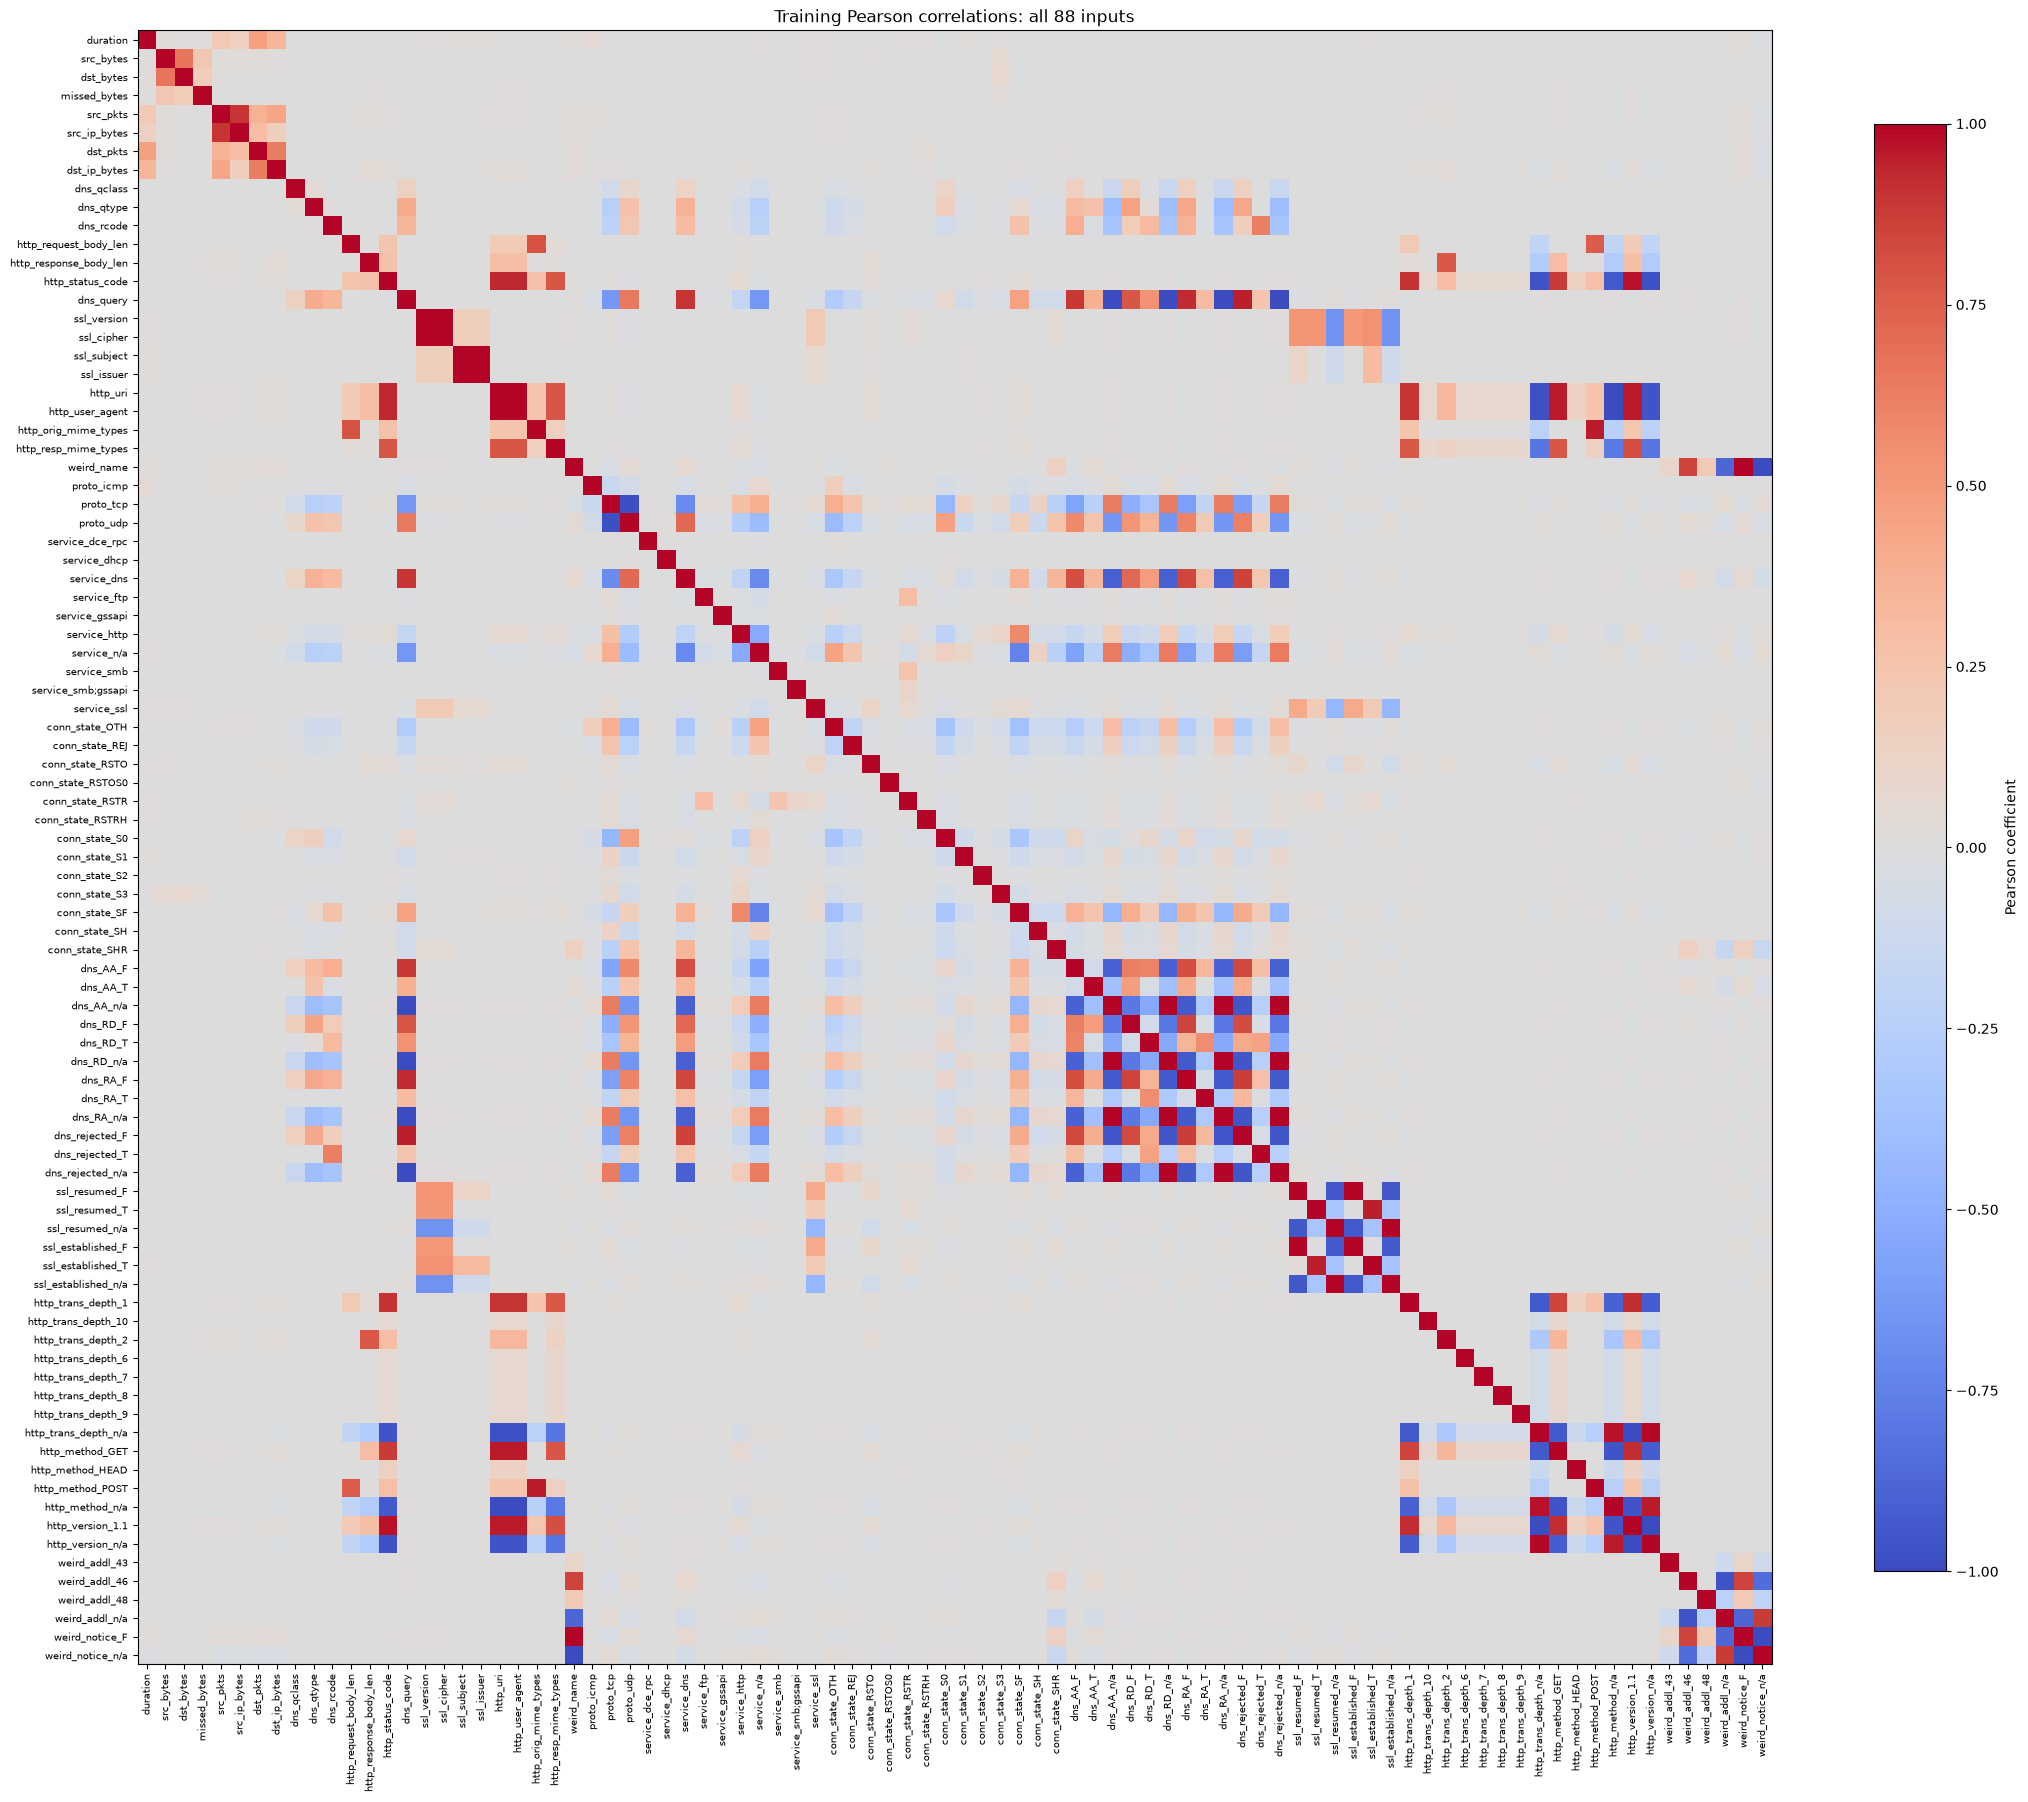

In [18]:
# 4.计算训练集 Pearson 关系并展示全部输入的分数
# 没有取值变化的列不能按通常公式计算相关系数
start = perf_counter()
constant_columns = feature_names[np.ptp(X_train, axis=0) == 0]
assert not len(constant_columns), f"恒定列无法直接计算 Pearson 系数：{constant_columns.tolist()}"
with threadpool_limits(limits=4):
    correlation_matrix = np.corrcoef(X_train, rowvar=False)
assert np.isfinite(correlation_matrix).all()
assert np.allclose(correlation_matrix, correlation_matrix.T)
assert np.allclose(np.diag(correlation_matrix), 1)
correlation_scores = correlation_matrix.mean(axis=0)
other_correlations = correlation_matrix.copy()
np.fill_diagonal(other_correlations, np.nan)
feature_scores = pd.DataFrame({
    "输入列名": feature_names,
    "平均有符号相关": correlation_scores,
    "与其他列平均绝对相关": np.nanmean(np.abs(other_correlations), axis=0),
    "与其他列最大绝对相关": np.nanmax(np.abs(other_correlations), axis=0),
})
correlation_seconds = perf_counter() - start
show_table(feature_scores)
correlation_table = pd.DataFrame(correlation_matrix, index=feature_names, columns=feature_names)

fig_correlation, ax = plt.subplots(figsize=(22, 20))
image = ax.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1, aspect="equal")
ax.set_xticks(np.arange(len(feature_names)), feature_names, rotation=90, fontsize=7)
ax.set_yticks(np.arange(len(feature_names)), feature_names, fontsize=7)
ax.set_title("Training Pearson correlations: all 88 inputs")
fig_correlation.colorbar(image, ax=ax, shrink=0.75, label="Pearson coefficient")
fig_correlation.tight_layout()
plt.show()

结论：恒定列检查通过，评分表和相关图均由训练集的全部 88 列计算。测试集未参与。表中平均有符号相关保留正负号，另外两项使用绝对值。它们衡量的内容不同，不能相互替代。

为了得到可比较的候选列集合，并避免按测试成绩反复选列，下一步使用固定阈值筛选平均有符号相关分数。

放宽分数范围，可以保留更多或相同数量的列。为了比较不同保留程度，本次设置逐步扩大的对称范围。阈值为 0.01、0.015、0.02、0.03 和 0.1。每个范围保留分数位于 −阈值到阈值的列。[范围设置参考](https://link.springer.com/content/pdf/10.1186/s40537-024-00892-y.pdf#page=25)提供了这组候选阈值的来源。

这些阈值属于固定的实验设置，尚无证据说明它们最适合当前数据。不同阈值可能选出同一集合，也可能没有入选列。所以先核对实际数量，再决定哪些候选可以进入比较。

若某范围保留全部输入，它与 Original 相同。若两个范围选出同一集合，也没有形成新的输入方案。为了避免重复计算，这两种情况不重复训练。没有入选列的情况只记录数量。

下面展示全部五个范围的数量。入选列明细只列分数落在对应范围内的列，未列出的列不满足该范围。这里的入选表示满足规则，不表示已经证实预测效果较好。

In [19]:
# 5.生成并核对各 Pearson 阈值对应的列集合
# 先按固定范围选列，再核对空集合、重复集合和全部输入
thresholds = [0.01, 0.015, 0.02, 0.03, 0.1]
selection_rows = []
selected_rows = []
fs_specs = []
used_column_sets = set()
for threshold in thresholds:
    selection_start = perf_counter()
    positions = np.flatnonzero(np.abs(correlation_scores) <= threshold)
    selection_seconds = perf_counter() - selection_start
    signature = tuple(positions.tolist())
    if len(positions) == X_train.shape[1]:
        status = "全部输入，与 Original 相同"
    elif not len(positions):
        status = "没有入选列，不训练"
    elif signature in used_column_sets:
        status = "与已有候选相同，不重复训练"
    else:
        status = "用于 FS 与同维数 PCA 比较"
        fs_specs.append({"threshold": threshold, "positions": positions,
                         "selection_seconds": selection_seconds})
        used_column_sets.add(signature)
    selection_rows.append({"阈值": threshold, "下界": -threshold, "上界": threshold,
                           "入选列数": len(positions), "处理": status})
    for position in positions:
        selected_rows.append({"阈值": threshold, "输入列名": feature_names[position],
                              "平均有符号相关": correlation_scores[position]})
threshold_summary = pd.DataFrame(selection_rows)
selected_features = pd.DataFrame(selected_rows)
assert fs_specs, "当前阈值没有形成可比较的降维候选"
assert len({len(spec["positions"]) for spec in fs_specs}) == len(fs_specs), "相同维数的不同集合需单独命名"
show_table(threshold_summary)
show_table(selected_features)

阈值,下界,上界,入选列数,处理
0.010000,-0.010000,0.010000,10,用于 FS 与同维数 PCA 比较
0.015000,-0.015000,0.015000,33,用于 FS 与同维数 PCA 比较
0.020000,-0.020000,0.020000,45,用于 FS 与同维数 PCA 比较
0.030000,-0.030000,0.030000,69,用于 FS 与同维数 PCA 比较
0.100000,-0.100000,0.100000,88,全部输入，与 Original 相同


阈值,输入列名,平均有符号相关
0.010000,proto_icmp,0.006575
0.010000,service_http,-0.001015
0.010000,conn_state_REJ,-0.006386
0.010000,conn_state_RSTRH,0.008300
0.010000,conn_state_S0,-0.006347
0.010000,conn_state_S1,0.002704
0.010000,conn_state_S2,0.009910
0.010000,conn_state_S3,0.008342
0.010000,conn_state_SH,0.001452
0.010000,conn_state_SHR,0.005609


结论：阈值 0.01、0.015、0.02、0.03 和 0.1 分别保留 10、33、45、69 和 88 列。最后一个范围保留全部输入，与 Original 相同。所以降维比较使用前四套候选，维数为 10、33、45、69。上表展示全部入选列，但还没有这些方案的检测结果。

训练和测试若使用不同的列或顺序，同一位置就可能表示不同信息。

所以下一步按训练集选定的列和顺序，提取两侧的 FS 输入。

In [20]:
# 6.按相同列顺序生成 FS 训练和测试输入
# 两侧使用同一组位置，保持入选列的含义与顺序一致
fs_inputs = {}
fs_shape_rows = []
for spec in fs_specs:
    positions = spec["positions"]
    dimensions = len(positions)
    start = perf_counter()
    train_values = np.ascontiguousarray(X_train[:, positions])
    train_select_seconds = perf_counter() - start
    start = perf_counter()
    test_values = np.ascontiguousarray(X_test[:, positions])
    test_select_seconds = perf_counter() - start
    assert train_values.shape == (len(y_train), dimensions)
    assert test_values.shape == (len(y_test), dimensions)
    fs_inputs[dimensions] = {
        "train": train_values, "test": test_values,
        "names": feature_names[positions], "threshold": spec["threshold"],
        "train_seconds": correlation_seconds + spec["selection_seconds"] + train_select_seconds,
        "test_seconds": test_select_seconds,
    }
    fs_shape_rows.append({"阈值": spec["threshold"], "输入列数": dimensions,
                          "训练形状": str(train_values.shape), "测试形状": str(test_values.shape)})
show_table(pd.DataFrame(fs_shape_rows))

阈值,输入列数,训练形状,测试形状
0.010000,10,"(360464, 10)","(89508, 10)"
0.015000,33,"(360464, 33)","(89508, 33)"
0.020000,45,"(360464, 45)","(89508, 45)"
0.030000,69,"(360464, 69)","(89508, 69)"


结论：四套 FS 输入的记录数保持不变。每套方案的训练与测试都使用相同列和顺序。FS 保留入选列中的原有数值。

训练准备时间包括相关分数计算和选列。相关分数实际只计算一次，但每套候选按独立使用该方案的口径计入这项开销。所以不能把各候选的准备时间相加，当作本次实际总耗时。

不同维数会同时改变表示方式和压缩程度。为了控制这个差异，下一步建立与各套 FS 维数相同的 PCA 输入。

FS 保留已有列。另一种减少维数的方式，是把多个输入组合成较少的新输入。为了比较这两种表示，采用 PCA 生成主成分。

每个主成分是原有输入的线性组合。PCA 优先保留方差较大的方向，不使用攻击标签选择方向。方差表示数据在该方向上的变化程度，不能直接说明攻击是否容易区分。[PCA 方法说明](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)给出了转换定义。

02 已用隔离训练集的范围完成 Min-Max 处理。为了让三种方案从相同输入出发，PCA 使用这份矩阵。PCA 会减去训练均值，但不会自动将各列除以标准差。所以当前结果仍受原有缩放方式影响。

为了与 FS 控制相同的压缩程度，主成分数分别等于各套 FS 的实际列数。为了避免随机近似影响主成分方向，计算使用完整 SVD。为了保留主成分原有的方差差异，不启用白化，不再把各主成分的方差统一为 1。

接下来是全部主成分的方差比例。四套候选分别绘图，每张图包含该方案保留的全部主成分。代码同时生成全部组合系数，用于追溯每个主成分由哪些输入组成。组合系数不直接表示攻击检测重要性。

主成分数,训练形状,测试形状,累计解释方差
10,"(360464, 10)","(89508, 10)",0.949925
33,"(360464, 33)","(89508, 33)",0.999522
45,"(360464, 45)","(89508, 45)",0.999952
69,"(360464, 69)","(89508, 69)",1.000000


方案维数,主成分,主成分序号,解释方差比例,累计解释方差
10,PC1,1,0.545198,0.545198
10,PC2,2,0.134102,0.679300
10,PC3,3,0.094231,0.773532
10,PC4,4,0.046404,0.819936
10,PC5,5,0.035816,0.855752
10,PC6,6,0.032453,0.888205
10,PC7,7,0.022575,0.910780
10,PC8,8,0.015479,0.926259
10,PC9,9,0.012627,0.938886
10,PC10,10,0.011040,0.949925


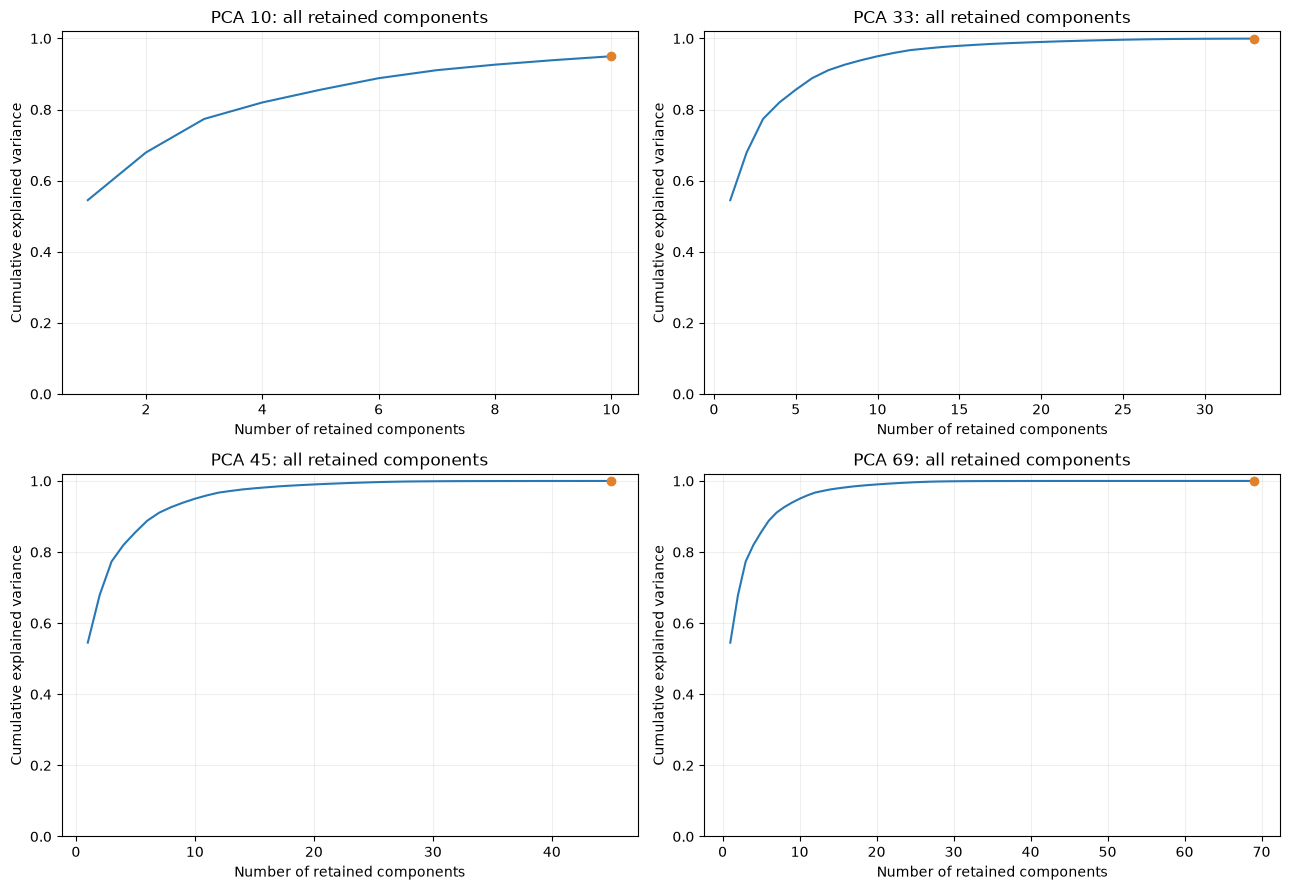

In [21]:
# 7.仅在训练集拟合同维数 PCA 并展示全部方差比例
# 主成分方向只根据训练记录确定，测试记录使用相同转换
pca_inputs = {}
pca_variance_rows = []
pca_loading_rows = []
pca_shape_rows = []
for dimensions in fs_inputs:
    pca = PCA(n_components=dimensions, svd_solver="full", whiten=False, copy=True)
    with threadpool_limits(limits=4):
        start = perf_counter()
        train_values = pca.fit_transform(X_train)
        train_prepare_seconds = perf_counter() - start
        start = perf_counter()
        test_values = pca.transform(X_test)
        test_transform_seconds = perf_counter() - start
    assert train_values.shape == (len(y_train), dimensions)
    assert test_values.shape == (len(y_test), dimensions)
    assert np.isfinite(train_values).all() and np.isfinite(test_values).all()
    pca_inputs[dimensions] = {
        "train": train_values, "test": test_values, "pca": pca,
        "train_seconds": train_prepare_seconds, "test_seconds": test_transform_seconds,
    }
    cumulative = np.cumsum(pca.explained_variance_ratio_)
    pca_shape_rows.append({"主成分数": dimensions, "训练形状": str(train_values.shape),
                          "测试形状": str(test_values.shape), "累计解释方差": cumulative[-1]})
    for position, (ratio, total) in enumerate(zip(pca.explained_variance_ratio_, cumulative)):
        component = f"PC{position + 1}"
        pca_variance_rows.append({"方案维数": dimensions, "主成分": component,
                                  "主成分序号": position + 1, "解释方差比例": ratio,
                                  "累计解释方差": total})
        for name, coefficient in zip(feature_names, pca.components_[position]):
            pca_loading_rows.append({"方案维数": dimensions, "主成分": component,
                                     "输入列名": name, "组合系数": coefficient})
pca_variance = pd.DataFrame(pca_variance_rows)
pca_loadings = pd.DataFrame(pca_loading_rows)
show_table(pd.DataFrame(pca_shape_rows))
show_table(pca_variance)
fig_variance, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (dimensions, group) in zip(axes.ravel(), pca_variance.groupby("方案维数", sort=False)):
    ax.plot(group["主成分序号"], group["累计解释方差"], color="#2878B5")
    ax.scatter(group["主成分序号"].iloc[-1], group["累计解释方差"].iloc[-1],
               color="#E1812C", zorder=3)
    ax.set_xlabel("Number of retained components")
    ax.set_ylabel("Cumulative explained variance")
    ax.set_ylim(0, 1.02)
    ax.set_title(f"PCA {dimensions}: all retained components")
    ax.grid(alpha=0.2)
fig_variance.tight_layout()
plt.show()

结论：四套 PCA 的主成分数分别为 10、33、45、69，与各自配对的 FS 相同。记录数保持不变。累计解释方差分别约为 94.9925%、99.9522%、99.9952% 和 100.0000%。这些比例来自训练集，表示保留的数据变化程度，不是检测准确率。

69 维的累计比例在当前显示精度下接近 100%，不能据此判断输入信息完全无损。

现在两种输入表示已经生成，但还没有对应的预测结果。为了比较检测效果，下一步在各套 FS 和 PCA 输入上训练 DT、RF。

In [22]:
# 8.在四个维数下训练 FS 与 PCA 的 DT、RF
for method, inputs in [("FS", fs_inputs), ("PCA", pca_inputs)]:
    for dimensions, values in inputs.items():
        for model_name in model_factories:
            evaluate_model(
                model_name, method, dimensions, values["train"], values["test"],
                values["train_seconds"], values["test_seconds"],
                values.get("threshold"),
            )
reduced_results = pd.DataFrame(result_rows)[lambda table: table["输入方案"] != "Original"]
show_table(reduced_results)

完成 DT × FS，输入 10 维
完成 RF × FS，输入 10 维
完成 DT × FS，输入 33 维
完成 RF × FS，输入 33 维
完成 DT × FS，输入 45 维
完成 RF × FS，输入 45 维
完成 DT × FS，输入 69 维
完成 RF × FS，输入 69 维
完成 DT × PCA，输入 10 维
完成 RF × PCA，输入 10 维
完成 DT × PCA，输入 33 维
完成 RF × PCA，输入 33 维
完成 DT × PCA，输入 45 维
完成 RF × PCA，输入 45 维
完成 DT × PCA，输入 69 维
完成 RF × PCA，输入 69 维


模型,输入方案,维数,Pearson阈值,Macro-F1,攻击召回率,攻击精确率,Accuracy,Weighted-F1,MCC,TN,FP,FN,TP,训练准备秒,测试转换秒,模型训练秒,模型预测秒,训练总秒,测试总秒,随机种子
DT,FS,10,0.010000,0.757752,0.758428,0.647196,0.772289,0.775834,0.521537,45526,12865,7517,23600,0.233595,0.003660,0.059065,0.002277,0.292660,0.005937,42
RF,FS,10,0.010000,0.721745,0.540219,0.710512,0.763641,0.754645,0.456732,51542,6849,14307,16810,0.233595,0.003660,1.928955,0.046148,2.162550,0.049808,42
DT,FS,33,0.015000,0.773793,0.805444,0.655602,0.785271,0.789319,0.558350,45225,13166,6054,25063,0.293992,0.012915,0.293705,0.003369,0.587697,0.016284,42
RF,FS,33,0.015000,0.732269,0.561462,0.718498,0.771071,0.763326,0.475599,51546,6845,13646,17471,0.293992,0.012915,2.708533,0.057112,3.002525,0.070027,42
DT,FS,45,0.020000,0.792393,0.849279,0.669190,0.801649,0.805750,0.599961,45327,13064,4690,26427,0.322723,0.017257,0.324282,0.003965,0.647005,0.021221,42
RF,FS,45,0.020000,0.785665,0.867821,0.652538,0.793404,0.798075,0.593696,44012,14379,4113,27004,0.322723,0.017257,2.823937,0.047537,3.146660,0.064793,42
DT,FS,69,0.030000,0.908272,0.973134,0.814115,0.913416,0.914891,0.825945,51477,6914,836,30281,0.443162,0.025595,0.833045,0.006174,1.276207,0.031769,42
RF,FS,69,0.030000,0.790949,0.880580,0.656311,0.798174,0.802792,0.606017,44042,14349,3716,27401,0.443162,0.025595,3.411478,0.057893,3.854639,0.083487,42
DT,PCA,10,nan,0.793275,0.848893,0.670738,0.802599,0.806653,0.601361,45424,12967,4702,26415,1.847252,0.007527,0.215809,0.002218,2.063061,0.009745,42
RF,PCA,10,nan,0.790920,0.849761,0.666683,0.800074,0.804250,0.597593,45171,13220,4675,26442,1.847252,0.007527,2.191528,0.044719,4.038780,0.052246,42


结论：四个维数下的 FS、PCA 均完成 DT 和 RF 训练。上表展示全部 16 个降维实验的指标和时间。

这张表只列出各方案的测试指标和耗时，尚未加入 Original，也未计算方案之间的差值。为了与基线比较并核对训练与测试表现，下一步汇总全部实验。


下一步将依次生成三张表。

为了比较降维方案与完整输入的差别，第一张表将加入两个 Original 基线，汇总全部 18 个实验。表格末尾将增加四列“相对Original的……变化”，分别对应 Macro-F1、攻击召回率、训练总秒和测试总秒。差值按当前方案减去同模型的 Original 计算。

为了比较相同维数下两种输入表示的差别，第二张表将列出全部八组 FS 与 PCA 配对。四个差值列名以“PCA减FS的……”开头，按同模型、同维数的 PCA 结果减去 FS 结果计算。两张表中，分数差值为正表示前者分数更高，时间差值为正表示前者耗时更长。

测试分数不能反映模型在训练记录上的表现，参数中的深度上限也不等于实际树深。所以第三张表将检查全部 18 个实验的训练与测试分数、树数量、树深范围和平均叶子数。RF 的树深范围和平均叶子数将根据全部 100 棵树计算。用于这项检查的预测不计入训练和测试总时间。

In [23]:
# 9.汇总全部实验并核对模型表现
# 汇总测试成绩之外，还检查训练成绩和全部已训练树的规模
# 这些检查不调整模型，也不计入第 2 步定义的训练与预测时间
results_summary = pd.DataFrame(result_rows)
assert len(results_summary) == 2 + 4 * len(fs_specs)
assert not results_summary.duplicated(["模型", "输入方案", "维数"]).any()
comparison_metrics = ["Macro-F1", "攻击召回率", "训练总秒", "测试总秒"]
baseline_lookup = results_summary[results_summary["输入方案"] == "Original"].set_index("模型")
for metric in comparison_metrics:
    results_summary[f"相对Original的{metric}变化"] = [
        row[metric] - baseline_lookup.loc[row["模型"], metric]
        for _, row in results_summary.iterrows()
    ]
show_table(results_summary)
paired_rows = []
for model_name in model_factories:
    for dimensions in fs_inputs:
        subset = results_summary[(results_summary["模型"] == model_name)
                                 & (results_summary["维数"] == dimensions)].set_index("输入方案")
        record = {"模型": model_name, "同条件维数": dimensions}
        for metric in comparison_metrics:
            record[f"PCA减FS的{metric}"] = subset.loc["PCA", metric] - subset.loc["FS", metric]
        paired_rows.append(record)
paired_comparison = pd.DataFrame(paired_rows)
show_table(paired_comparison)

model_diagnostic_rows = []
for row in result_rows:
    key = f"{row['模型']}_{row['输入方案']}_{row['维数']}"
    estimator = trained_models[key]
    if row["输入方案"] == "Original":
        train_values = X_train
    elif row["输入方案"] == "FS":
        train_values = fs_inputs[row["维数"]]["train"]
    else:
        train_values = pca_inputs[row["维数"]]["train"]
    expected_params = model_factories[row["模型"]]().get_params()
    assert estimator.get_params() == expected_params
    assert estimator.n_features_in_ == row["维数"]
    with threadpool_limits(limits=4):
        train_predicted = estimator.predict(train_values)
    train_macro_f1 = f1_score(y_train, train_predicted, average="macro", zero_division=0)
    trees = [estimator] if row["模型"] == "DT" else estimator.estimators_
    depths = [tree.get_depth() for tree in trees]
    leaves = [tree.get_n_leaves() for tree in trees]
    if row["模型"] == "RF":
        assert len(trees) == 100 and max(depths) <= 5
    model_diagnostic_rows.append({
        "模型": row["模型"], "输入方案": row["输入方案"], "维数": row["维数"],
        "训练Macro-F1": train_macro_f1, "测试Macro-F1": row["Macro-F1"],
        "训练减测试Macro-F1": train_macro_f1 - row["Macro-F1"],
        "训练Accuracy": accuracy_score(y_train, train_predicted),
        "测试Accuracy": row["Accuracy"],
        "树数量": len(trees), "实际最小树深": min(depths), "实际最大树深": max(depths),
        "平均叶子数": float(np.mean(leaves)),
    })
model_diagnostics = pd.DataFrame(model_diagnostic_rows)
assert len(model_diagnostics) == len(results_summary)
show_table(model_diagnostics)


模型,输入方案,维数,Pearson阈值,Macro-F1,攻击召回率,攻击精确率,Accuracy,Weighted-F1,MCC,TN,FP,FN,TP,训练准备秒,测试转换秒,模型训练秒,模型预测秒,训练总秒,测试总秒,随机种子,相对Original的Macro-F1变化,相对Original的攻击召回率变化,相对Original的训练总秒变化,相对Original的测试总秒变化
DT,Original,88,nan,0.915203,0.985089,0.820476,0.919884,0.921274,0.840390,51684,6707,464,30653,0.000000,0.000000,1.163313,0.007567,1.163313,0.007567,42,0.000000,0.000000,0.000000,0.000000
RF,Original,88,nan,0.837757,0.986920,0.690516,0.841679,0.845443,0.715490,44627,13764,407,30710,0.000000,0.000000,3.731135,0.069363,3.731135,0.069363,42,0.000000,0.000000,0.000000,0.000000
DT,FS,10,0.010000,0.757752,0.758428,0.647196,0.772289,0.775834,0.521537,45526,12865,7517,23600,0.233595,0.003660,0.059065,0.002277,0.292660,0.005937,42,-0.157451,-0.226661,-0.870653,-0.001630
RF,FS,10,0.010000,0.721745,0.540219,0.710512,0.763641,0.754645,0.456732,51542,6849,14307,16810,0.233595,0.003660,1.928955,0.046148,2.162550,0.049808,42,-0.116012,-0.446701,-1.568585,-0.019555
DT,FS,33,0.015000,0.773793,0.805444,0.655602,0.785271,0.789319,0.558350,45225,13166,6054,25063,0.293992,0.012915,0.293705,0.003369,0.587697,0.016284,42,-0.141410,-0.179645,-0.575616,0.008717
RF,FS,33,0.015000,0.732269,0.561462,0.718498,0.771071,0.763326,0.475599,51546,6845,13646,17471,0.293992,0.012915,2.708533,0.057112,3.002525,0.070027,42,-0.105487,-0.425459,-0.728611,0.000664
DT,FS,45,0.020000,0.792393,0.849279,0.669190,0.801649,0.805750,0.599961,45327,13064,4690,26427,0.322723,0.017257,0.324282,0.003965,0.647005,0.021221,42,-0.122810,-0.135810,-0.516308,0.013654
RF,FS,45,0.020000,0.785665,0.867821,0.652538,0.793404,0.798075,0.593696,44012,14379,4113,27004,0.322723,0.017257,2.823937,0.047537,3.146660,0.064793,42,-0.052092,-0.119099,-0.584475,-0.004570
DT,FS,69,0.030000,0.908272,0.973134,0.814115,0.913416,0.914891,0.825945,51477,6914,836,30281,0.443162,0.025595,0.833045,0.006174,1.276207,0.031769,42,-0.006931,-0.011955,0.112894,0.024201
RF,FS,69,0.030000,0.790949,0.880580,0.656311,0.798174,0.802792,0.606017,44042,14349,3716,27401,0.443162,0.025595,3.411478,0.057893,3.854639,0.083487,42,-0.046808,-0.106341,0.123504,0.014124


模型,同条件维数,PCA减FS的Macro-F1,PCA减FS的攻击召回率,PCA减FS的训练总秒,PCA减FS的测试总秒
DT,10,0.035523,0.090465,1.770401,0.003808
DT,33,0.032897,0.047305,2.149580,-0.002777
DT,45,0.098044,0.126394,2.746576,-0.004785
DT,69,0.008264,0.014044,5.705794,-0.007538
RF,10,0.069175,0.309541,1.876230,0.002437
RF,33,0.071879,0.287463,2.004990,-0.013045
RF,45,0.018634,-0.018896,2.572403,-0.007207
RF,69,0.029454,-0.028795,4.483720,-0.008476


模型,输入方案,维数,训练Macro-F1,测试Macro-F1,训练减测试Macro-F1,训练Accuracy,测试Accuracy,树数量,实际最小树深,实际最大树深,平均叶子数
DT,Original,88,0.984825,0.915203,0.069622,0.985910,0.919884,1,36,36,1014.000000
RF,Original,88,0.917370,0.837757,0.079613,0.920993,0.841679,100,5,5,24.540000
DT,FS,10,0.791733,0.757752,0.033981,0.816636,0.772289,1,10,10,17.000000
RF,FS,10,0.740119,0.721745,0.018375,0.796823,0.763641,100,5,5,9.560000
DT,FS,33,0.857214,0.773793,0.083421,0.867845,0.785271,1,19,19,57.000000
RF,FS,33,0.740368,0.732269,0.008099,0.797003,0.771071,100,5,5,14.160000
DT,FS,45,0.873463,0.792393,0.081070,0.882013,0.801649,1,21,21,158.000000
RF,FS,45,0.867563,0.785665,0.081898,0.875491,0.793404,100,5,5,18.260000
DT,FS,69,0.967157,0.908272,0.058885,0.969700,0.913416,1,41,41,1106.000000
RF,FS,69,0.876540,0.790949,0.085591,0.883472,0.798174,100,5,5,24.080000


结论：同模型、同维数的八组配对中，PCA 的 Macro-F1 均高于 FS。DT 的四组攻击召回率也均更高。RF 在 10、33 维时更高，在 45、69 维时更低。八组 PCA 的训练总时间均更长，测试总时间没有一致方向。

Original 的 DT 实际树深为 36。训练 Macro-F1 为 0.984825，测试为 0.915203。RF 的全部树深为 5，训练 Macro-F1 为 0.917370，测试为 0.837757。两者训练分数均高于测试分数。这个差值本身还不能区分过拟合、划分差异或输入信息损失。

这些观察对应当前选列规则、缩放和模型参数。目前只使用一次划分和一个随机种子，所以分数差值不能直接证明统计显著性，耗时差值也不能证明稳定的速度优势。测试成绩用于报告本次比较，不用于重新调整参数。[测试集使用说明](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage)有支持的阐述。

平均分数不能直接显示漏报和误报数量。

所以下一步查看全部混淆矩阵。

同一个分数可能对应不同的误报和漏报数量。为了区分这两种错误，下面展示全部 18 个实验的混淆矩阵和计数表。

矩阵行表示真实类别，列表示预测类别。Normal 表示正常，Attack 表示攻击。四个位置分别记录：

TN,FP,FN,TP（前面已经解释了）

全部矩阵使用同一颜色范围。颜色表示数量，具体记录数标在格内。

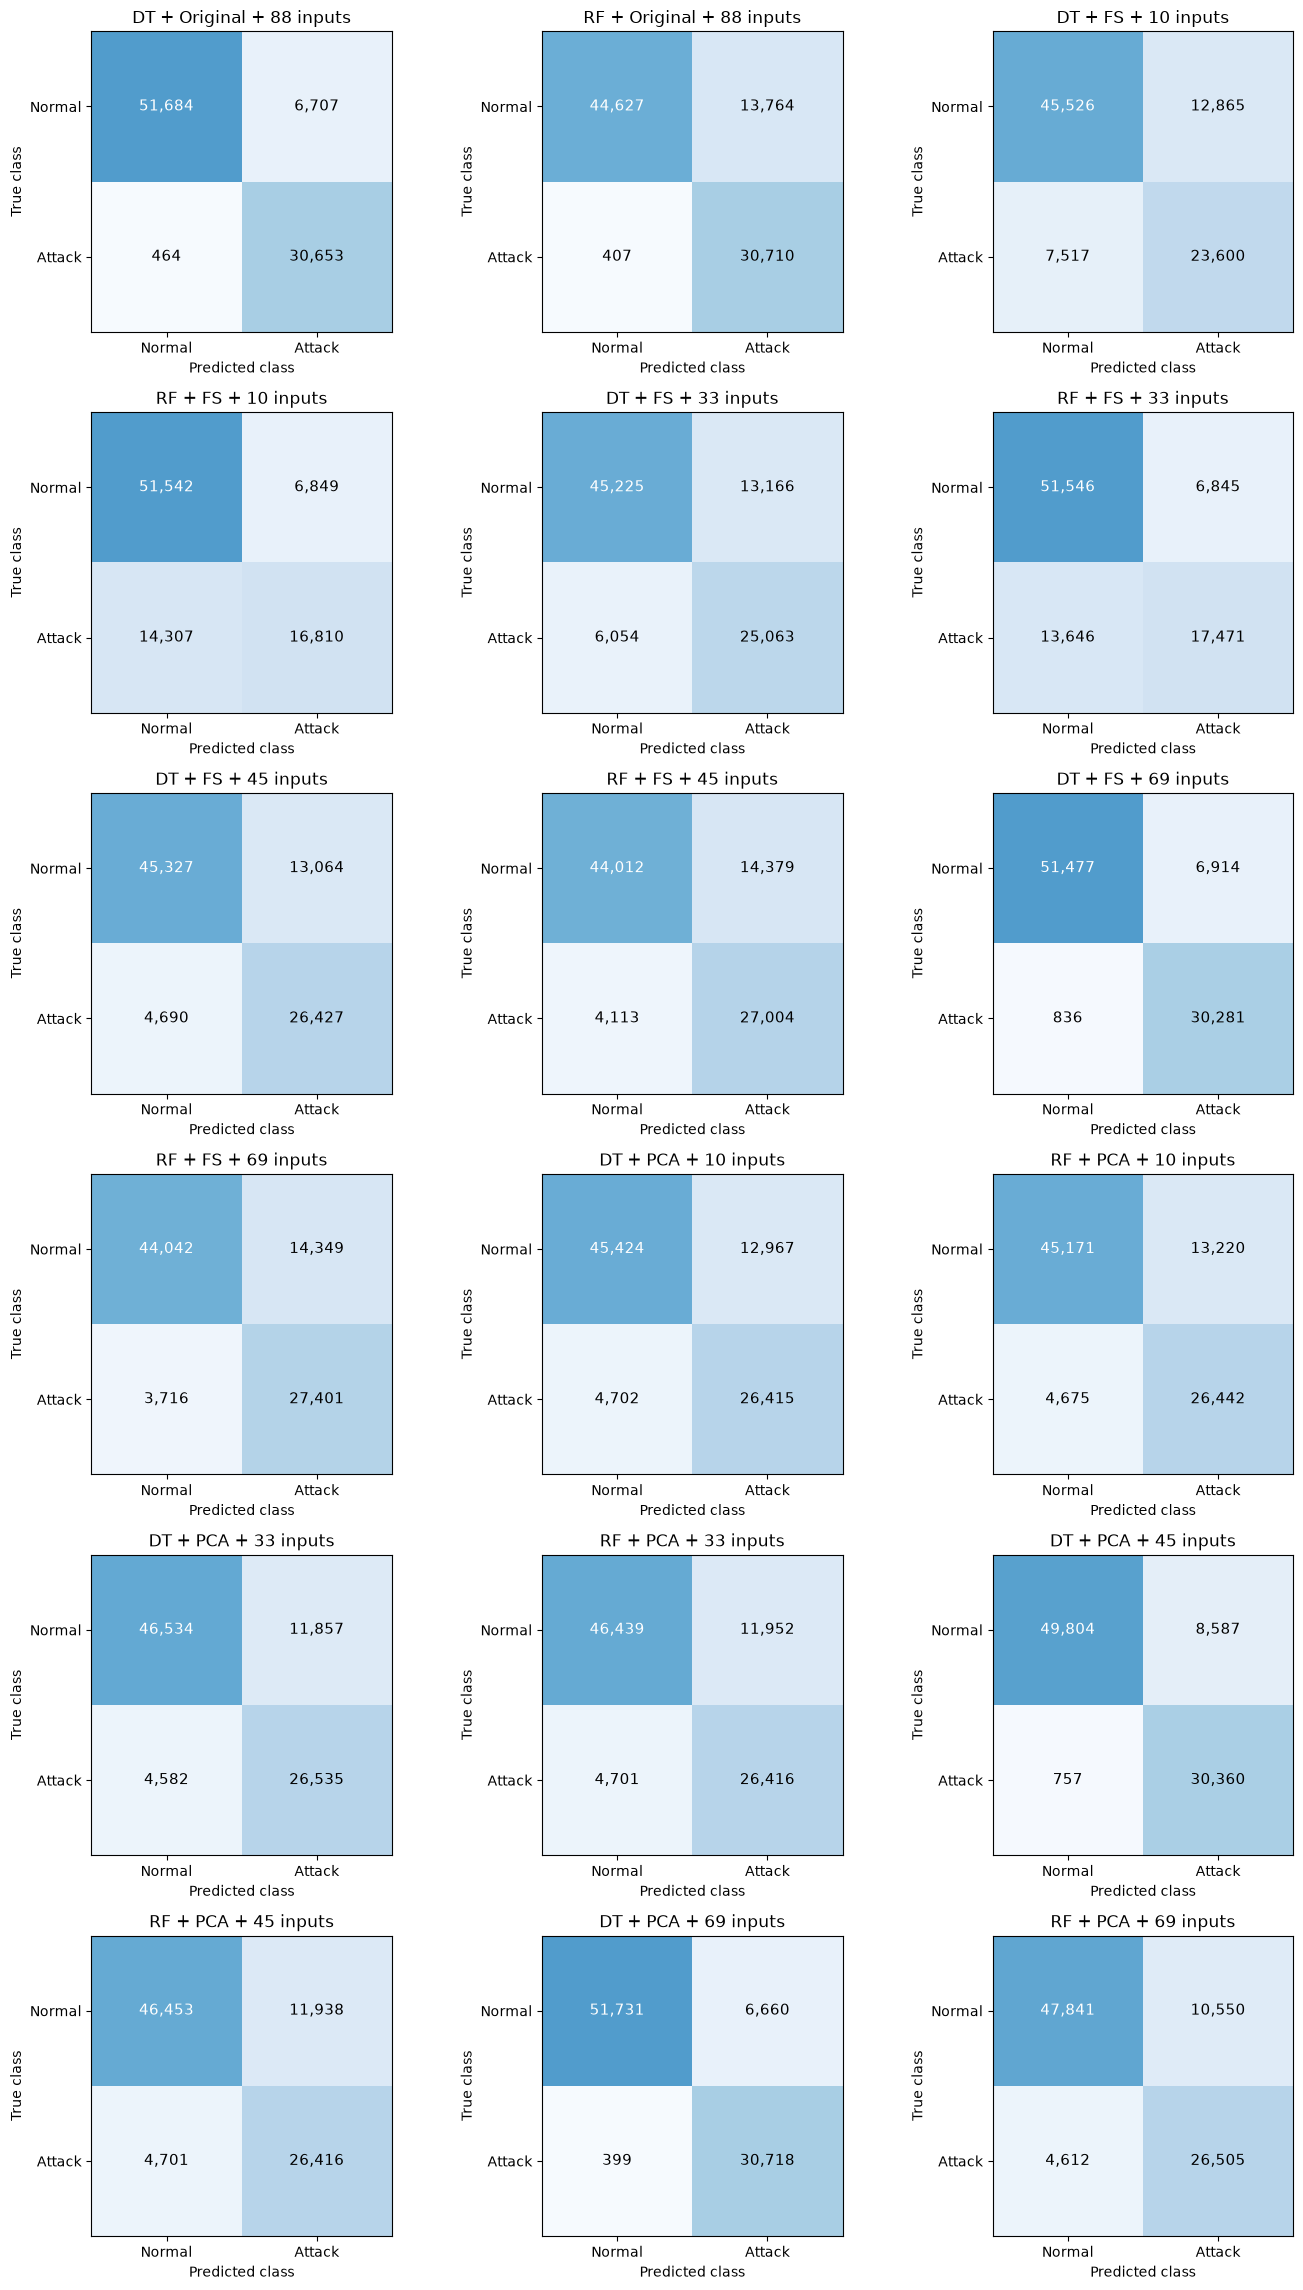

模型,输入方案,维数,TN,FP,FN,TP
DT,Original,88,51684,6707,464,30653
RF,Original,88,44627,13764,407,30710
DT,FS,10,45526,12865,7517,23600
RF,FS,10,51542,6849,14307,16810
DT,FS,33,45225,13166,6054,25063
RF,FS,33,51546,6845,13646,17471
DT,FS,45,45327,13064,4690,26427
RF,FS,45,44012,14379,4113,27004
DT,FS,69,51477,6914,836,30281
RF,FS,69,44042,14349,3716,27401


In [24]:
# 10.展示全部实验的混淆矩阵
fig_confusion, axes = plt.subplots(6, 3, figsize=(14, 23))
for ax, row in zip(axes.ravel(), result_rows):
    key = f"{row['模型']}_{row['输入方案']}_{row['维数']}"
    matrix = confusion_matrix(y_test, predictions[key], labels=[0, 1])
    ax.imshow(matrix, cmap="Blues", vmin=0, vmax=len(y_test))
    for (i, j), count in np.ndenumerate(matrix):
        ax.text(j, i, f"{count:,}", ha="center", va="center",
                color="white" if count > len(y_test) * 0.45 else "black", fontsize=11)
    ax.set_xticks([0, 1], ["Normal", "Attack"])
    ax.set_yticks([0, 1], ["Normal", "Attack"])
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_title(f"{row['模型']} + {row['输入方案']} + {row['维数']} inputs")
fig_confusion.tight_layout()
plt.show()
confusion_counts = results_summary[["模型", "输入方案", "维数", "TN", "FP", "FN", "TP"]]
show_table(confusion_counts)

结论：全部 18 个混淆矩阵和计数表使用同一批预测。四类计数覆盖完整测试集。FP（正常误报），FN（攻击漏报），二者需要同时比较。

混淆矩阵将所有攻击合并统计，无法显示各攻击类型的漏报情况。02 已保留每条测试记录的攻击类型，所以接下来按全部九种攻击类型分别统计检出和漏报。

当前模型只判断正常或攻击。某条攻击记录被预测为攻击，就计为检出。但是这不表示模型正确识别了具体攻击名称。各类型召回率等于该类型的检出数除以测试记录数。正常记录的误报已经在上一步统计。

In [ ]:
# 11.统计全部九种攻击类型的检出与漏报
# 只统计攻击类型，正常误报已经在上一步核对
attack_types = sorted(set(test_type) - {"normal"})
attack_recall_rows = []
for row in result_rows:
    key = f"{row['模型']}_{row['输入方案']}_{row['维数']}"
    predicted = predictions[key]
    for traffic_type in attack_types:
        mask = test_type == traffic_type
        total = int(mask.sum())
        detected = int((predicted[mask] == 1).sum())
        attack_recall_rows.append({
            "模型": row["模型"], "输入方案": row["输入方案"], "维数": row["维数"],
            "攻击类型": traffic_type, "测试记录数": total, "检出数": detected,
            "漏报数": total - detected, "攻击类型召回率": detected / total,
        })
attack_type_results = pd.DataFrame(attack_recall_rows)
assert len(attack_type_results) == len(result_rows) * len(attack_types)
for _, block in attack_type_results.groupby(["模型", "输入方案", "维数"]):
    assert block["测试记录数"].sum() == int((y_test == 1).sum())
show_table(attack_type_results)

模型,输入方案,维数,攻击类型,测试记录数,检出数,漏报数,攻击类型召回率
DT,Original,88,backdoor,4000,3998,2,0.999500
DT,Original,88,ddos,4000,3981,19,0.995250
DT,Original,88,dos,4000,3981,19,0.995250
DT,Original,88,injection,4000,3987,13,0.996750
DT,Original,88,mitm,209,187,22,0.894737
DT,Original,88,password,4000,3987,13,0.996750
DT,Original,88,ransomware,4000,3715,285,0.928750
DT,Original,88,scanning,3277,3256,21,0.993592
DT,Original,88,xss,3631,3561,70,0.980722
RF,Original,88,backdoor,4000,3999,1,0.999750


结论：上表展示全部 18 个实验在九种攻击类型上的检出和漏报，共 162 条结果。各类型的测试记录数不同，mitm 为 209 条。

上表用于查看各攻击类型的检出和漏报。第 9 步的汇总表记录了各实验的整体检测指标和耗时。为了更直观地比较输入方案，

下一步根据第 9 步的汇总表绘制对照图。

整个项目关注整体检测表现、攻击漏报和计算开销。所以图中选取四项指标：Macro-F1 （正常与攻击两类的综合表现—），攻击召回率（反映攻击检出情况），训练总时间和测试总时间（两阶段的计算开销）。攻击精确率、Accuracy、Weighted-F1 和 MCC 还是保留在第 9 步的汇总表中。但是这四项图示不覆盖全部评价角度。

接下来图中会展示 DT、RF 各自的全部九种输入方案。颜色固定为 Original 蓝色、FS 橙色、PCA 绿色。


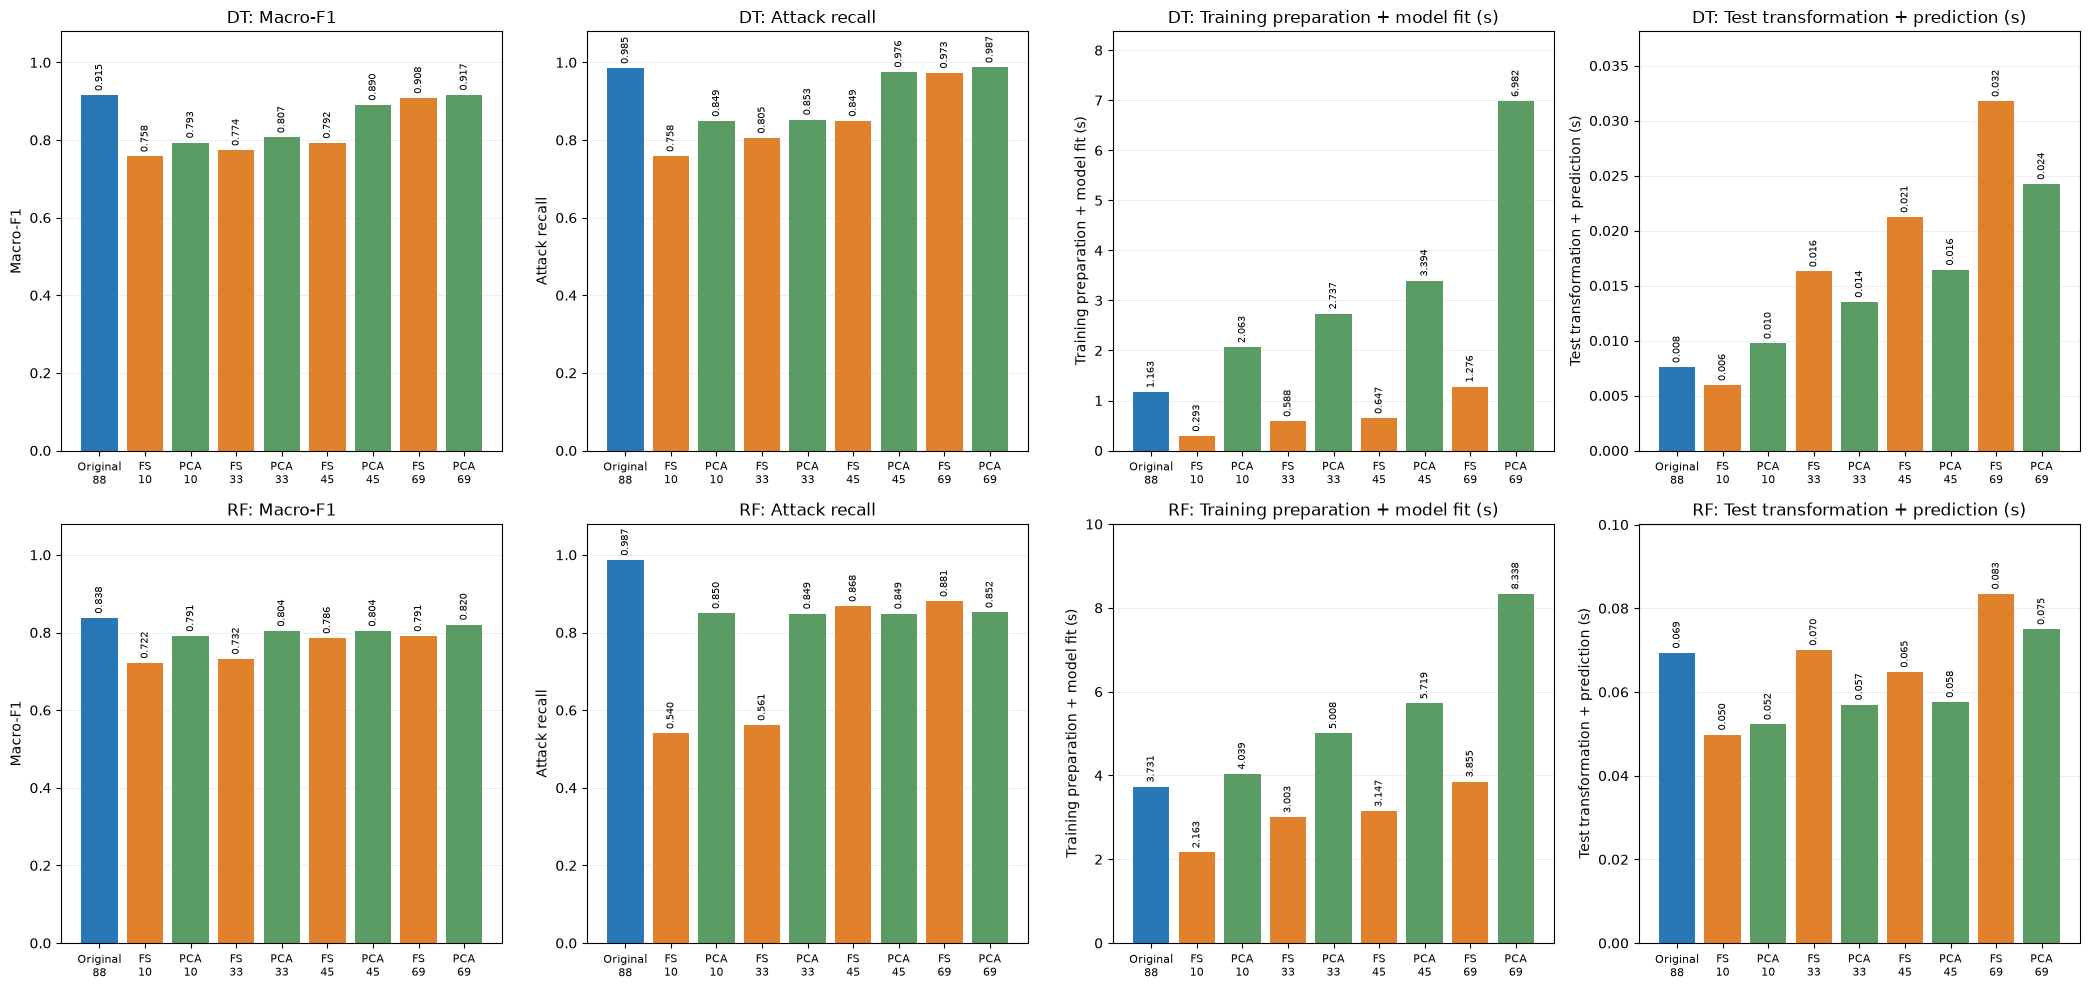

In [26]:
# 12.绘制全部输入方案的性能与耗时对照
scheme_order = [("Original", 88)]
for dimensions in fs_inputs:
    scheme_order.extend([("FS", dimensions), ("PCA", dimensions)])
labels = [f"{method}\n{dimensions}" for method, dimensions in scheme_order]
fig_comparison, axes = plt.subplots(2, 4, figsize=(21, 10))
plot_metrics = [("Macro-F1", "Macro-F1"), ("攻击召回率", "Attack recall"),
                ("训练总秒", "Training preparation + model fit (s)"),
                ("测试总秒", "Test transformation + prediction (s)")]
colors = {"Original": "#2878B5", "FS": "#E1812C", "PCA": "#5B9B64"}
for row_position, model_name in enumerate(model_factories):
    subset = results_summary[results_summary["模型"] == model_name].set_index(["输入方案", "维数"])
    for column_position, (metric, label) in enumerate(plot_metrics):
        ax = axes[row_position, column_position]
        values = [subset.loc[(method, dimensions), metric] for method, dimensions in scheme_order]
        bars = ax.bar(np.arange(len(labels)), values,
                      color=[colors[method] for method, _ in scheme_order])
        ax.set_xticks(np.arange(len(labels)), labels, fontsize=8)
        ax.set_ylabel(label)
        ax.set_title(f"{model_name}: {label}")
        if column_position < 2:
            ax.set_ylim(0, 1.08)
        else:
            ax.set_ylim(0, max(values) * 1.2)
        ax.bar_label(bars, fmt="%.3f", fontsize=7, padding=3, rotation=90)
        ax.grid(axis="y", alpha=0.2)
        ax.set_axisbelow(True)
fig_comparison.tight_layout()
plt.show()

结论：对照图展示 DT、RF 各自的全部九种输入方案。两种模型的四个 PCA 方案输入列数均少于 Original，但训练总时间均高于各自的 Original。所以在这些 PCA 方案中，输入列数减少没有带来训练总时间下降。这里的训练总时间包括输入准备和模型训练。具体耗时仍受当前运行条件影响。

04的结论阐述需要读取可核对的结果文件。

所以接下来保存完整表格、测试预测、方法设置和图形。保存后，重新读取 11 份结果表核对列名和记录数，并进一步核对汇总表中的指标、计数、时间以及预测文件中的数组。Pearson 相关矩阵、方法设置和图形在本步骤中仅保存，不进行重新读取核对。


In [27]:
# 13.保存完整结果并核对结果表和预测数组
import os
import tempfile

assert hashlib.sha256(X_train.tobytes()).hexdigest() == train_digest
assert hashlib.sha256(X_test.tobytes()).hexdigest() == test_digest
assert hashlib.sha256(input_path.read_bytes()).hexdigest() == input_sha256
output_dir = root / "results" / "03_features_and_models"
figure_dir = output_dir / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

def save_csv(table, name, index=False):
    target = output_dir / name
    temporary_path = None
    try:
        with tempfile.NamedTemporaryFile(mode="w", encoding="utf-8-sig", newline="",
                                         dir=output_dir, suffix=".csv", delete=False) as temporary:
            temporary_path = Path(temporary.name)
            table.to_csv(temporary, index=index)
        os.replace(temporary_path, target)
    finally:
        if temporary_path is not None and temporary_path.exists():
            temporary_path.unlink()
    return target

tables_to_save = {
    "results_summary.csv": results_summary,
    "fs_pca_comparison.csv": paired_comparison,
    "model_parameters.csv": model_parameters,
    "model_diagnostics.csv": model_diagnostics,
    "input_distribution.csv": type_distribution,
    "feature_scores.csv": feature_scores,
    "fs_thresholds.csv": threshold_summary,
    "fs_selected_features.csv": selected_features,
    "pca_variance.csv": pca_variance,
    "pca_loadings.csv": pca_loadings,
    "attack_type_recall.csv": attack_type_results,
}
table_descriptions = {
    "results_summary.csv": "全部实验的指标、耗时及相对基线的变化",
    "fs_pca_comparison.csv": "同模型、同维数下 PCA 与 FS 的差值",
    "model_parameters.csv": "DT 和 RF 的完整参数设置",
    "model_diagnostics.csv": "训练与测试分数、树数量、树深和叶子数",
    "input_distribution.csv": "训练集与测试集的流量类型分布",
    "feature_scores.csv": "全部输入列的平均有符号 Pearson 相关分数",
    "fs_thresholds.csv": "全部候选阈值及对应的入选列数",
    "fs_selected_features.csv": "各阈值下的入选列名与相关分数",
    "pca_variance.csv": "各主成分的方差保留比例及累计比例",
    "pca_loadings.csv": "各主成分对应原始输入列的组合系数",
    "attack_type_recall.csv": "全部实验按攻击类型统计的检出、漏报和召回率",
}
figure_descriptions = {
    "pearson_matrix.png": "全部输入列之间的 Pearson 相关矩阵图",
    "pca_variance.png": "各 PCA 方案的累计方差保留比例图",
    "confusion_matrices.png": "全部 18 个实验的混淆矩阵图",
    "performance_and_time.png": "DT、RF 全部输入方案的检测表现与耗时对照图",
}
artifact_rows = []
for name, table in tables_to_save.items():
    target = save_csv(table, name)
    reloaded = pd.read_csv(target)
    assert len(reloaded) == len(table) and reloaded.columns.tolist() == table.columns.tolist()
    artifact_rows.append({"文件": str(target.relative_to(root)), "内容": table_descriptions[name],
                          "记录数": len(table)})
correlation_path = save_csv(correlation_table, "pearson_matrix.csv", index=True)
artifact_rows.append({"文件": str(correlation_path.relative_to(root)), "内容": "全部 Pearson 系数",
                      "记录数": len(correlation_table)})

prediction_payload = {"y_test": y_test, "test_index": test_index, "test_type": test_type,
                      **predictions}
prediction_path = output_dir / "test_predictions.npz"
with tempfile.NamedTemporaryFile(dir=output_dir, suffix=".npz", delete=False) as temporary:
    temporary_path = Path(temporary.name)
    np.savez_compressed(temporary, **prediction_payload)
try:
    os.replace(temporary_path, prediction_path)
finally:
    if temporary_path.exists():
        temporary_path.unlink()
with np.load(prediction_path, allow_pickle=False) as stored:
    assert set(stored.files) == set(prediction_payload)
    for key, values in prediction_payload.items():
        assert np.array_equal(stored[key], values), key
artifact_rows.append({"文件": str(prediction_path.relative_to(root)), "内容": "全部测试预测与对应标签",
                      "记录数": len(y_test)})

experiment_settings = {
    "split": "exact_input_group_holdout", "input_file": str(input_path.relative_to(root)),
    "input_sha256": input_sha256, "raw_sha256": raw_sha256,
    "train_rows": len(y_train), "test_rows": len(y_test), "original_dimensions": len(feature_names),
    "feature_names": feature_names.tolist(), "random_seed": random_seed,
    "thresholds": thresholds, "fs_dimensions": list(fs_inputs),
    "score_definition": "signed Pearson column mean including self correlation",
    "pca": {"input": "Min-Max from 02", "solver": "full", "whiten": False},
    "model_parameters": {name: factory().get_params() for name, factory in model_factories.items()},
    "timing": {"train_total": "representation preparation plus estimator fit",
               "test_total": "representation transformation plus estimator prediction",
               "excluded": ["02 preparation", "file input/output", "metrics", "plots"],
               "linear_algebra_threads": 4,
               "diagnostic_prediction": "training predictions in model diagnostics excluded",
               "fs_score_time": "one full score computation allocated to each standalone FS candidate"},
    "versions": {"python": platform.python_version(), "numpy": np.__version__,
                 "pandas": pd.__version__, "sklearn": sklearn.__version__, "matplotlib": matplotlib.__version__},
    "result_rows": len(results_summary),
}
settings_path = output_dir / "experiment_settings.json"
settings_path.write_text(json.dumps(experiment_settings, ensure_ascii=False, indent=2) + "\n",
                         encoding="utf-8")
artifact_rows.append({"文件": str(settings_path.relative_to(root)), "内容": "数据版本和完整实验设置",
                      "记录数": 1})
for figure, name in [(fig_correlation, "pearson_matrix.png"), (fig_variance, "pca_variance.png"),
                     (fig_confusion, "confusion_matrices.png"), (fig_comparison, "performance_and_time.png")]:
    target = figure_dir / name
    figure.savefig(target, dpi=160, bbox_inches="tight")
    artifact_rows.append({"文件": str(target.relative_to(root)), "内容": figure_descriptions[name], "记录数": 1})
restored_results = pd.read_csv(output_dir / "results_summary.csv")
for column in ["维数", "TN", "FP", "FN", "TP", "随机种子"]:
    np.testing.assert_array_equal(restored_results[column], results_summary[column])
for column in ["Macro-F1", "攻击召回率", "攻击精确率", "Accuracy", "Weighted-F1", "MCC",
               "训练准备秒", "测试转换秒", "模型训练秒", "模型预测秒", "训练总秒", "测试总秒"]:
    np.testing.assert_allclose(restored_results[column], results_summary[column], rtol=1e-12, atol=1e-12)
show_table(pd.DataFrame(artifact_rows))

文件,内容,记录数
results/03_features_and_models/results_summary.csv,全部实验的指标、耗时及相对基线的变化,18
results/03_features_and_models/fs_pca_comparison.csv,同模型、同维数下 PCA 与 FS 的差值,8
results/03_features_and_models/model_parameters.csv,DT 和 RF 的完整参数设置,32
results/03_features_and_models/model_diagnostics.csv,训练与测试分数、树数量、树深和叶子数,18
results/03_features_and_models/input_distribution.csv,训练集与测试集的流量类型分布,10
results/03_features_and_models/feature_scores.csv,全部输入列的平均有符号 Pearson 相关分数,88
results/03_features_and_models/fs_thresholds.csv,全部候选阈值及对应的入选列数,5
results/03_features_and_models/fs_selected_features.csv,各阈值下的入选列名与相关分数,245
results/03_features_and_models/pca_variance.csv,各主成分的方差保留比例及累计比例,157
results/03_features_and_models/pca_loadings.csv,各主成分对应原始输入列的组合系数,13816


结论：结果文件已保存到 `results/03_features_and_models`。预测文件重新读取后，各数组与保存前一致。11 份结果表已核对列名和记录数，其中汇总表核对了指标、计数和时间。Pearson 相关矩阵、实验设置和图形已保存，但未对它们进行重新读取核对。02 的输入文件在保存结果前通过了哈希一致性检查。

DT 的最高测试 Macro-F1 来自 PCA 69 维，为 0.916536。Original 为 0.915203，两者差值只有 0.001333。RF 的最高值来自 Original 88 维，为 0.837757。这些是本次测试集上的观测排序，还不能认定为最终最优方案。

03在两种模型内部比较输入表示。每组 FS 与 PCA 的维数相同，Original 保留全部 88 列。同一方案的训练与测试使用一致的列定义和顺序。不同方案的列含义不同，FS 的已有列与 PCA 的主成分不能逐列对应。

FS 的含义可以按入选列名追溯。PCA 需要结合组合系数解释。03只使用一份数据、一次隔离划分和一个随机种子，结果限于当前配置。

下一步由 04 观察 `results_summary.csv` 和 `test_predictions.npz`。